In [13]:
import numpy as np
from google.colab.patches import cv2_imshow
import cv2

# đọc các file ảnh và tiền xử lý để các ảnh có cùng kích thước: hàm imread và hàm resize

bg1_image = cv2.imread('GreenBackground.png', 1)
bg1_image = cv2.resize(bg1_image, (678, 381))

ob_image = cv2.imread('Object.png', 1)
ob_image = cv2.resize(ob_image, (678, 381))

bg2_image = cv2.imread('NewBackground.jpg', 1)
bg2_image = cv2.resize(bg2_image, (678, 381))

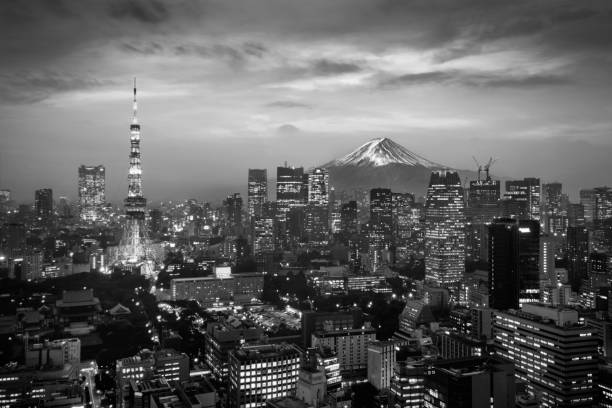

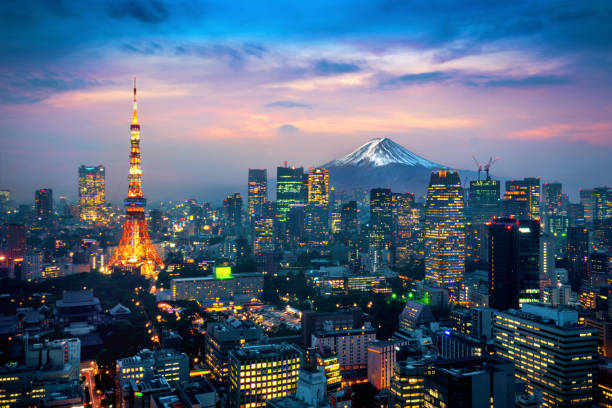

In [12]:
# ví dụ cách đọc ảnh màu / ảnh xám trong cv2
gray_img = cv2.imread('NewBackground.jpg', 0) # số 0 là xám
color_img = cv2.imread('NewBackground.jpg', 1) # số 1 là màu

cv2_imshow(gray_img)
cv2_imshow(color_img)

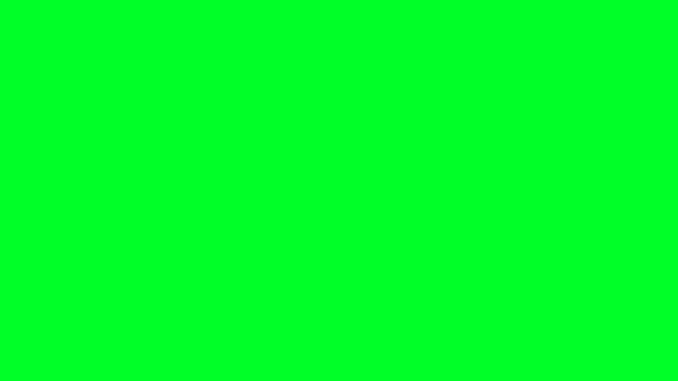

(381, 678, 3)


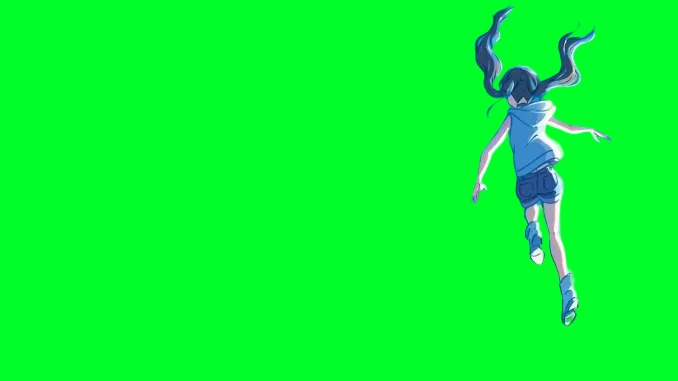

(381, 678, 3)


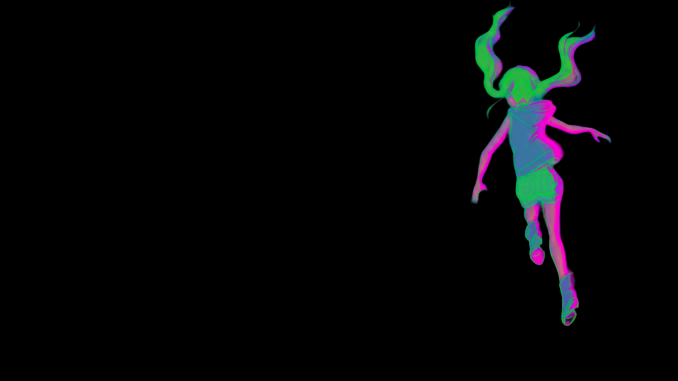

In [18]:
# So sánh 2 hình: hình nền xanh và hình cô gái trên nền xanh
def computeDifference(bg_img, input_img):
    # khác nhau giữa 2 ảnh => vẫn còn ảnh (w, h, c) - c gồm rgb
    difference_three_channel = cv2.absdiff(bg_img, input_img)
    # chuyển sang ảnh 3 chiều
    difference_single_channel = np.sum(difference_three_channel, axis=2) / 3.0
    # chuyển từ float 64 => int8
    difference_single_channel = difference_single_channel.astype('uint8')

    return difference_single_channel


#####################################################
cv2_imshow(bg1_image)
print(bg1_image.shape)
cv2_imshow(ob_image)
print(ob_image.shape)
dif = cv2.absdiff(bg1_image, ob_image)
cv2_imshow(dif)

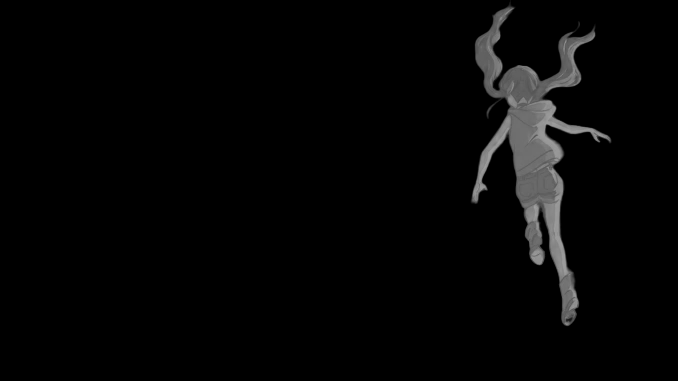

In [3]:
difference_single_channel = computeDifference(bg1_image, ob_image)
cv2_imshow(difference_single_channel)

In [4]:
def computeBinaryMask(difference_single_channel):
    difference_binary = np.where(difference_single_channel >= 15, 255, 0)
    difference_binary = np.stack((difference_binary,)*3, axis=-1)
    return difference_binary

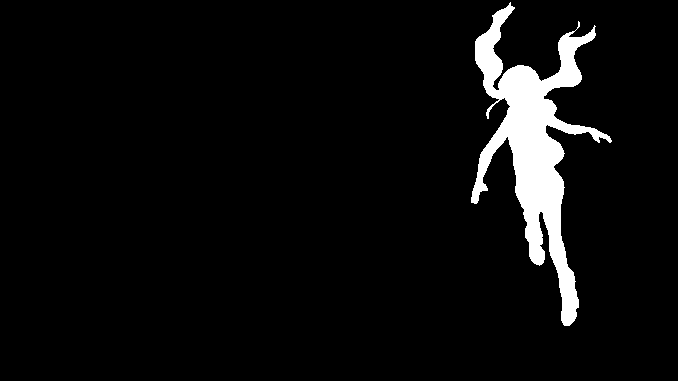

In [5]:
binary_mask = computeBinaryMask(difference_single_channel)
cv2_imshow(binary_mask)

In [6]:
def replaceBackGround(bg1_image, bg2_image, ob_image):
    difference_single_channel = computeDifference(bg1_image,ob_image)
    binary_mask = computeBinaryMask(difference_single_channel)

    output = np.where(binary_mask==255, ob_image, bg2_image)

    return output

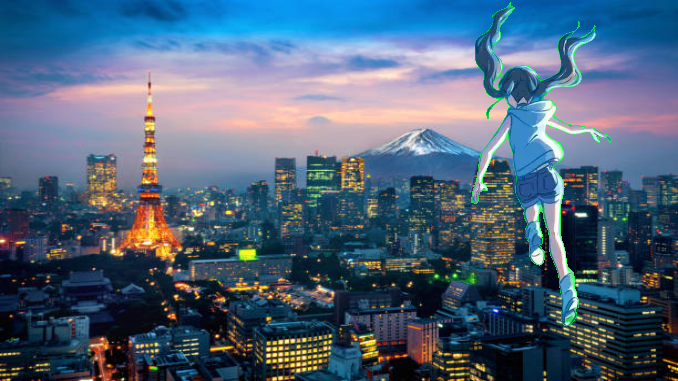

In [7]:
output = replaceBackGround(bg1_image, bg2_image, ob_image)

cv2_imshow(output)